# Telco Customer Churn — Modelling & Evaluation

**Goal:** Train and compare churn prediction models, lock a decision
threshold without letting the test set influence that choice, and
evaluate honestly on held-out data.

This notebook covers:
1. Load the pre-split, leakage-safe feature matrices from notebook 02
2. A majority-class baseline, for context
3. Train three models: Logistic Regression, Random Forest, XGBoost
4. Compare models on AUC-ROC, PR-AUC, F1 — on the test set, but only for
   *reporting*, never for making a decision that then gets evaluated on
   that same test set
5. Cross-validated threshold selection — **on training data only**
6. One final, locked-threshold evaluation on test
7. Calibration check
8. Model interpretation (feature importances, SHAP)
9. Error and subgroup analysis

> **Design note on threshold selection:** the previous version of this
> notebook chose its decision threshold by maximizing F1 directly on the
> test set predictions, then reported business metrics using that same
> threshold on that same test set — a textbook case of the test set
> leaking into a modeling decision, then grading its own homework. This
> version picks the threshold using 5-fold cross-validated out-of-fold
> predictions on the training set only, locks it, and touches the test
> set exactly once, at the end, for a single unbiased evaluation.
>
> Business-impact / retention-targeting simulation and the assumption
> sensitivity analysis live in a separate notebook,
> `04_retention_strategy.ipynb`, which consumes this notebook's locked
> threshold and test-set predictions rather than re-deriving them.


## 1. Setup

In [70]:
import sys
import json as jsonlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, f1_score, brier_score_loss,
)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier
import joblib

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
%matplotlib inline

RANDOM_STATE = 42


## 2. Load the pre-split feature matrices

Loads `telco_features_train.csv` and `telco_features_test.csv` from
notebook 02 — **no re-splitting here**. Both files were already built with
the split happening before any fitted transformation (median threshold,
one-hot encoding), so this is the correct, leakage-safe pair to model on.


In [71]:
TARGET = 'Churn_Binary'

train_df = pd.read_csv('../data/telco_features_train.csv')
test_df = pd.read_csv('../data/telco_features_test.csv')

for name, d in [('Train', train_df), ('Test', test_df)]:
    obj_cols = d.select_dtypes(include='object').columns.tolist()
    assert not obj_cols, f"{name} has non-numeric columns: {obj_cols}"
    assert d.isnull().sum().sum() == 0, f"{name} has nulls — rerun notebook 02"

feature_cols = [c for c in train_df.columns if c != TARGET]

X_train, y_train = train_df[feature_cols], train_df[TARGET]
X_test, y_test = test_df[feature_cols], test_df[TARGET]

print(f"Train: {X_train.shape[0]:,} rows, {X_train.shape[1]} features   (churn rate: {y_train.mean():.1%})")
print(f"Test:  {X_test.shape[0]:,} rows, {X_test.shape[1]} features   (churn rate: {y_test.mean():.1%})")


Train: 5,625 rows, 21 features   (churn rate: 26.6%)
Test:  1,407 rows, 21 features   (churn rate: 26.6%)


In [72]:
# Scale for Logistic Regression only — fit on train, applied to test.
# Random Forest and XGBoost are scale-invariant, so they train on
# unscaled data to keep feature importances interpretable in original units.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 3. Baseline

Before trusting any model's numbers, establish what a trivial classifier
gets — always predicting the majority class (no churn). AUC-ROC and PR-AUC
aren't meaningful for a classifier with constant output, so we report
accuracy/precision/recall/F1 instead, which make the point just as clearly:
a majority-class guess gets zero recall on churners, by construction.


In [73]:
baseline = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

baseline_report = classification_report(y_test, baseline_pred, output_dict=True, zero_division=0)
print("Majority-class baseline (always predicts 'no churn'):")
print(f"  Accuracy:          {baseline_report['accuracy']:.3f}  (this alone looks deceptively fine — it's just the no-churn rate)")
print(f"  Precision (churn): {baseline_report['1']['precision']:.3f}")
print(f"  Recall (churn):    {baseline_report['1']['recall']:.3f}")
print(f"  F1 (churn):        {baseline_report['1']['f1-score']:.3f}")
print()
print("Any model worth using needs to clear F1=0 on the churn class by a real margin —")
print("that's the bar the baseline sets, not 'high accuracy.'")


Majority-class baseline (always predicts 'no churn'):
  Accuracy:          0.734  (this alone looks deceptively fine — it's just the no-churn rate)
  Precision (churn): 0.000
  Recall (churn):    0.000
  F1 (churn):        0.000

Any model worth using needs to clear F1=0 on the churn class by a real margin —
that's the bar the baseline sets, not 'high accuracy.'


## 4. Train candidate models

In [74]:
# ── Logistic Regression ───────────────────────────────────────────────────────
lr = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr.fit(X_train_scaled, y_train)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
lr_pred = lr.predict(X_test_scaled)
print("Logistic Regression trained.")


Logistic Regression trained.


In [75]:
# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=5,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1,
)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)
print("Random Forest trained.")


Random Forest trained.


In [76]:
# ── XGBoost ───────────────────────────────────────────────────────────────────
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg / pos

xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos, eval_metric='logloss',
    random_state=RANDOM_STATE, n_jobs=-1,
)
xgb.fit(X_train, y_train)
xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_pred = xgb.predict(X_test)
print(f"XGBoost trained.  (scale_pos_weight = {scale_pos:.2f})")


XGBoost trained.  (scale_pos_weight = 2.76)


## 5. Model comparison (test set — for reporting only)

These test-set numbers are for *comparing* the three trained models against
each other and the baseline. Nothing here selects a threshold or otherwise
feeds back into a decision that gets graded on this same test set — that
happens later, using cross-validation on training data only.


In [77]:
def summarise(name, y_true, y_pred, y_proba):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return {
        'Model': name,
        'AUC-ROC': round(roc_auc_score(y_true, y_proba), 4),
        'PR-AUC': round(average_precision_score(y_true, y_proba), 4),
        'F1 (churn)': round(report['1']['f1-score'], 4),
        'Recall (churn)': round(report['1']['recall'], 4),
        'Precision (churn)': round(report['1']['precision'], 4),
    }

results = pd.DataFrame([
    summarise('Logistic Regression', y_test, lr_pred, lr_proba),
    summarise('Random Forest', y_test, rf_pred, rf_proba),
    summarise('XGBoost', y_test, xgb_pred, xgb_proba),
])
results


,Model,AUC-ROC,PR-AUC,F1 (churn),Recall (churn),Precision (churn)
0,Logistic Regression,0.8374,0.6540,0.6109,0.7914,0.4975
1,Random Forest,0.8336,0.6359,0.6203,0.7273,0.5408
2,XGBoost,0.8283,0.6283,0.6137,0.7540,0.5174


✍️ **YOUR INTERPRETATION HERE**

- Which model has the best AUC-ROC / PR-AUC? By how much?
- **Is the gap worth it?** If XGBoost edges out Logistic Regression by a
  small margin, is that worth losing direct coefficient interpretability?
  Write the actual case for whichever model you carry forward — "XGBoost
  wins" isn't an answer, "XGBoost's AUC is X vs LR's Y, a Z-point gap,
  which [is / isn't] worth the interpretability trade-off because ___" is.
- Which model do you choose to carry forward for threshold locking,
  interpretation, and notebook 4? (The cells below default to XGBoost —
  change `chosen_model` / `chosen_proba` below if you pick differently.)


In [78]:
# Set which trained model carries forward through the rest of this notebook.
chosen_name = 'XGBoost'
chosen_model = xgb
chosen_proba = xgb_proba
chosen_pred = xgb_pred


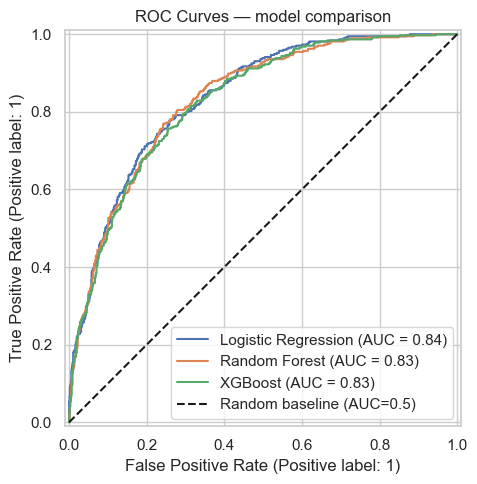

In [79]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, proba in [('Logistic Regression', lr_proba), ('Random Forest', rf_proba), ('XGBoost', xgb_proba)]:
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Random baseline (AUC=0.5)')
ax.set_title('ROC Curves — model comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../data/plots/roc_curves.png', dpi=150)
plt.show()


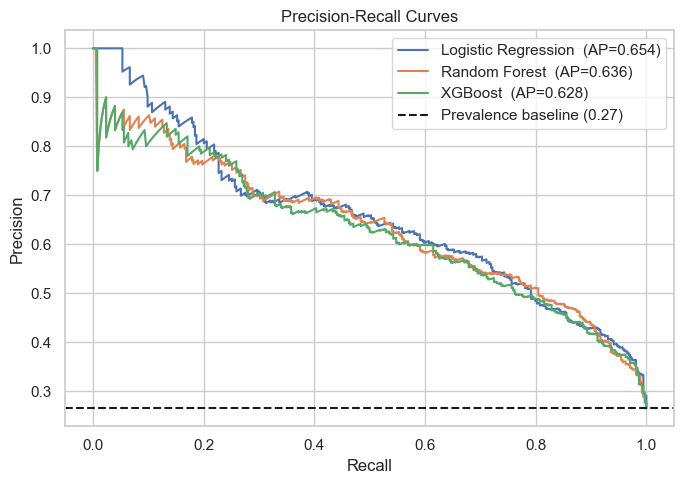

In [80]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, proba in [('Logistic Regression', lr_proba), ('Random Forest', rf_proba), ('XGBoost', xgb_proba)]:
    p, r, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(r, p, label=f'{name}  (AP={ap:.3f})')
ax.axhline(y_test.mean(), color='k', linestyle='--', label=f'Prevalence baseline ({y_test.mean():.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend()
plt.tight_layout()
plt.savefig('../data/plots/pr_curves.png', dpi=150)
plt.show()


## 6. Cross-validation stability check

A single train/test split can be lucky or unlucky. 5-fold stratified CV on
AUC-ROC, run on **training data only**, confirms results are stable across
different splits before we trust any of them enough to lock a threshold.


In [81]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model, X_cv in [
    ('Logistic Regression', lr, X_train_scaled),
    ('Random Forest', rf, X_train.values),
    ('XGBoost', xgb, X_train.values),
]:
    scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f"{name:<25}  CV AUC: {scores.mean():.4f} ± {scores.std():.4f}  [{scores.min():.4f} – {scores.max():.4f}]")


Logistic Regression        CV AUC: 0.8475 ± 0.0074  [0.8410 – 0.8595]
Random Forest              CV AUC: 0.8451 ± 0.0063  [0.8364 – 0.8531]
XGBoost                    CV AUC: 0.8421 ± 0.0058  [0.8353 – 0.8504]


## 7. Threshold selection — cross-validated, on training data only

The default 0.5 threshold is rarely optimal for an imbalanced problem, and
the right threshold genuinely depends on business costs (explored properly
in notebook 04). But *choosing* that threshold has to happen without
touching test data.

**Method:** get out-of-fold predicted probabilities for every training
example via 5-fold cross-validation (`cross_val_predict`) — each fold's
predictions come from a model that never saw that fold during training, so
this is a legitimate, leakage-free proxy for "how would this model score
unseen data." Sweep thresholds against those out-of-fold predictions, pick
the one that maximizes F1, and lock it. The test set is not used anywhere
in this section.


Locked threshold (from CV out-of-fold predictions on TRAIN only): 0.50
  Out-of-fold F1 at this threshold: 0.631


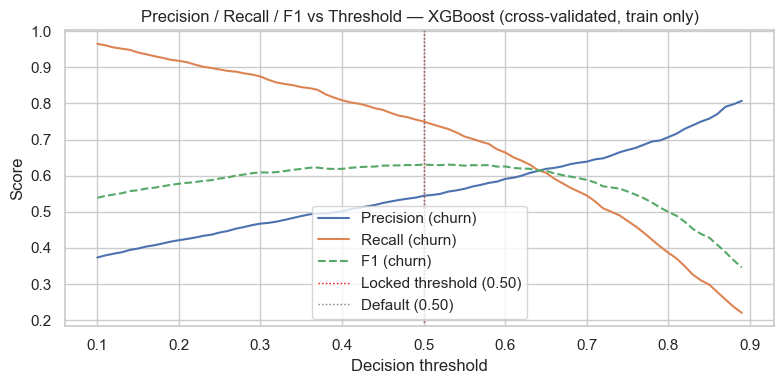

In [82]:
cv_for_threshold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

oof_proba = cross_val_predict(
    chosen_model, X_train, y_train,
    cv=cv_for_threshold, method='predict_proba', n_jobs=-1,
)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    preds = (oof_proba >= t).astype(int)
    report = classification_report(y_train, preds, output_dict=True, zero_division=0)
    precisions.append(report['1']['precision'])
    recalls.append(report['1']['recall'])
    f1s.append(report['1']['f1-score'])

locked_threshold = float(thresholds[np.argmax(f1s)])
print(f"Locked threshold (from CV out-of-fold predictions on TRAIN only): {locked_threshold:.2f}")
print(f"  Out-of-fold F1 at this threshold: {max(f1s):.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, precisions, label='Precision (churn)')
ax.plot(thresholds, recalls, label='Recall (churn)')
ax.plot(thresholds, f1s, label='F1 (churn)', linestyle='--')
ax.axvline(locked_threshold, color='red', linewidth=1, linestyle=':', label=f'Locked threshold ({locked_threshold:.2f})')
ax.axvline(0.5, color='grey', linewidth=1, linestyle=':', label='Default (0.50)')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title(f'Precision / Recall / F1 vs Threshold — {chosen_name} (cross-validated, train only)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/plots/threshold_analysis.png', dpi=150)
plt.show()


## 8. Final test evaluation — locked threshold, touched once

This is the only place the test set is used to evaluate a decision. The
threshold above was chosen without it.


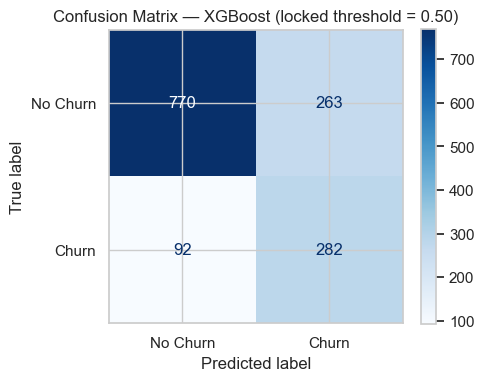

              precision    recall  f1-score   support

    No Churn       0.89      0.75      0.81      1033
       Churn       0.52      0.75      0.61       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.71      1407
weighted avg       0.79      0.75      0.76      1407



In [83]:
final_preds = (chosen_proba >= locked_threshold).astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, final_preds, display_labels=['No Churn', 'Churn'], cmap='Blues', ax=ax,
)
ax.set_title(f'Confusion Matrix — {chosen_name} (locked threshold = {locked_threshold:.2f})')
plt.tight_layout()
plt.savefig('../data/plots/confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_test, final_preds, target_names=['No Churn', 'Churn']))


## 9. Calibration

A model used to drive real retention decisions needs probabilities that
mean what they say — a predicted 0.7 should correspond to roughly 70%
actual churn among customers scored near that probability. The reliability
diagram and Brier score check this directly.


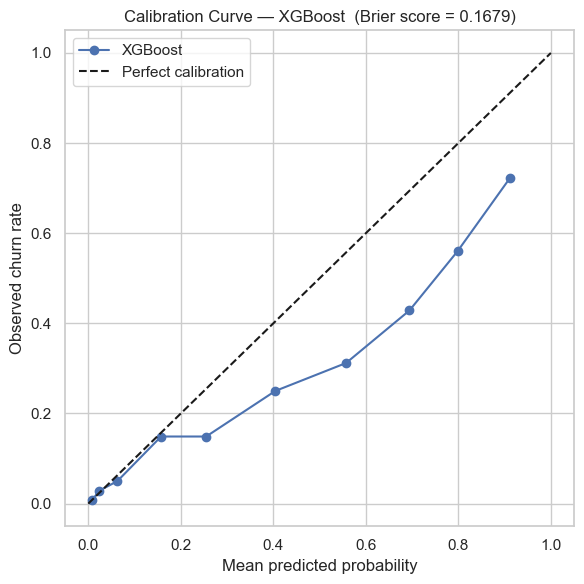

Brier score: 0.1679  (lower is better; 0 = perfect, 0.25 = uninformative for a 50/50 base rate)


In [84]:
prob_true, prob_pred = calibration_curve(y_test, chosen_proba, n_bins=10, strategy='quantile')
brier = brier_score_loss(y_test, chosen_proba)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(prob_pred, prob_true, marker='o', label=chosen_name)
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed churn rate')
ax.set_title(f'Calibration Curve — {chosen_name}  (Brier score = {brier:.4f})')
ax.legend()
plt.tight_layout()
plt.savefig('../data/plots/calibration_curve.png', dpi=150)
plt.show()

print(f"Brier score: {brier:.4f}  (lower is better; 0 = perfect, 0.25 = uninformative for a 50/50 base rate)")


✍️ **YOUR INTERPRETATION HERE**

- Does the curve sit close to the diagonal, or does it systematically
  over/under-predict in some probability range?
- If it's miscalibrated, that matters directly for notebook 04 — expected-value
  calculations there assume predicted probabilities are roughly trustworthy.


## 10. Model interpretation — feature importances

1. **XGBoost feature importances** — which features the model relied on most
2. **Logistic Regression coefficients** — directly interpretable as
   log-odds contributions (positive = increases churn probability)


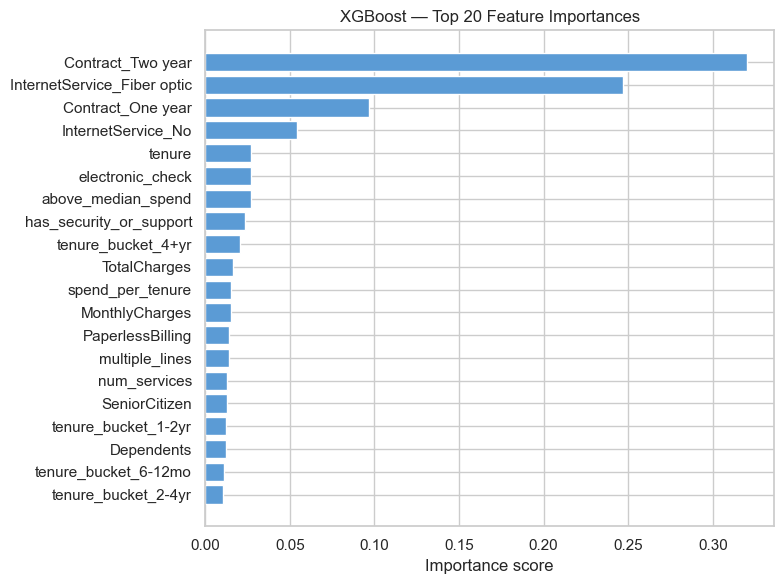

In [85]:
importance_df = (pd.DataFrame({'Feature': X_train.columns, 'Importance': xgb.feature_importances_})
                 .sort_values('Importance', ascending=True).tail(20))

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance_df['Feature'], importance_df['Importance'], color='#5B9BD5')
ax.set_title('XGBoost — Top 20 Feature Importances')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig('../data/plots/xgb_feature_importance.png', dpi=150)
plt.show()


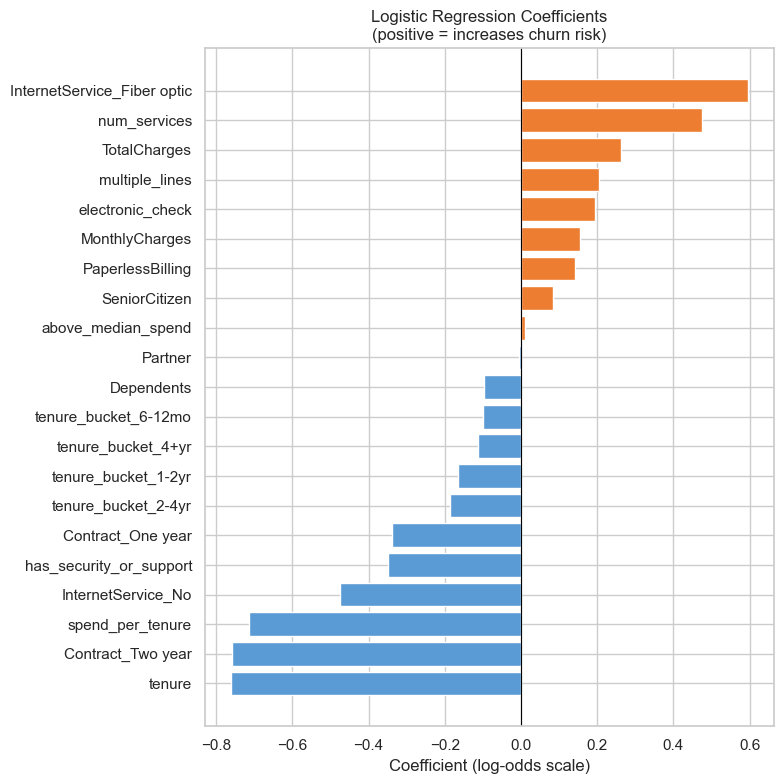

In [86]:
coef_df = (pd.DataFrame({'Feature': X_train.columns, 'Coefficient': lr.coef_[0]})
           .sort_values('Coefficient', ascending=True))

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#ED7D31' if c > 0 else '#5B9BD5' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients\n(positive = increases churn risk)')
ax.set_xlabel('Coefficient (log-odds scale)')
plt.tight_layout()
plt.savefig('../data/plots/lr_coefficients.png', dpi=150)
plt.show()


**What to look for:**
- Features at the far right of the LR plot **increase** churn probability; far left **decrease** it
- Compare rankings between XGBoost and LR — consistent top features across both are the most reliable signals


## 10b. SHAP — explaining individual predictions

SHAP assigns each feature a contribution score for every single prediction —
not just which features matter globally, but *how much* each one pushed the
model's output for one specific customer. That's the kind of explanation a
retention team can act on: "Customer #1234 was flagged mainly because they're
on a month-to-month contract and have only been a customer for 2 months."


In [87]:
!{sys.executable} -m pip install shap -q
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer(X_test)

print(f"SHAP values shape: {shap_values.values.shape}  (one row per test customer, one column per feature)")


SHAP values shape: (1407, 21)  (one row per test customer, one column per feature)


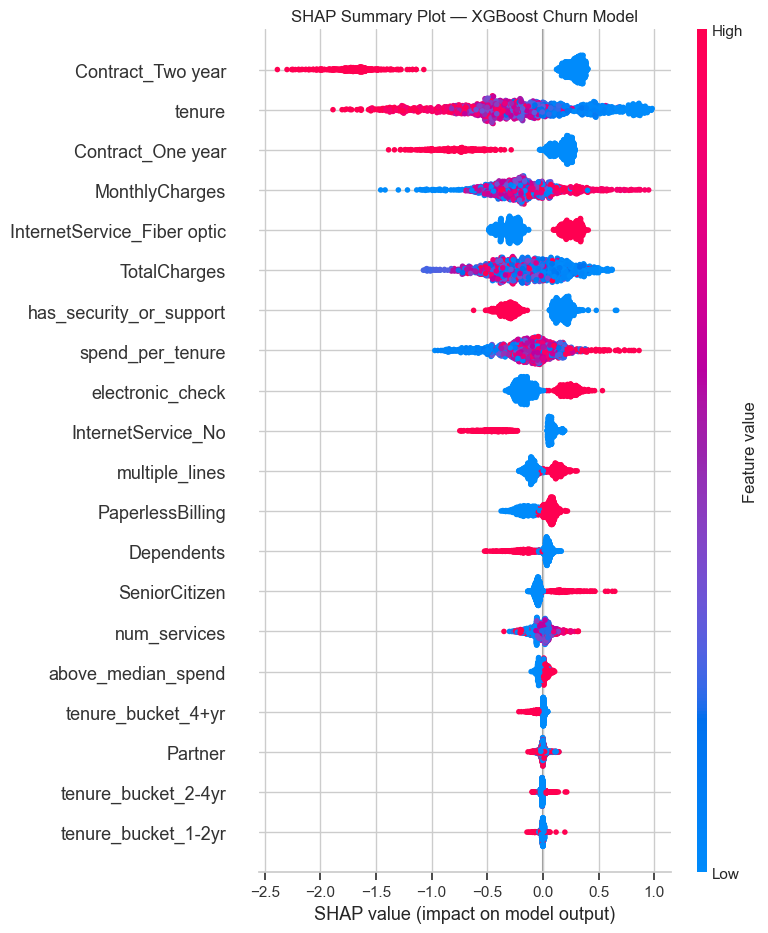

In [88]:
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot — XGBoost Churn Model")
plt.tight_layout()
plt.savefig('../data/plots/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()


Customer index: 591
Predicted churn probability: 98.1%
Actual churn: Yes


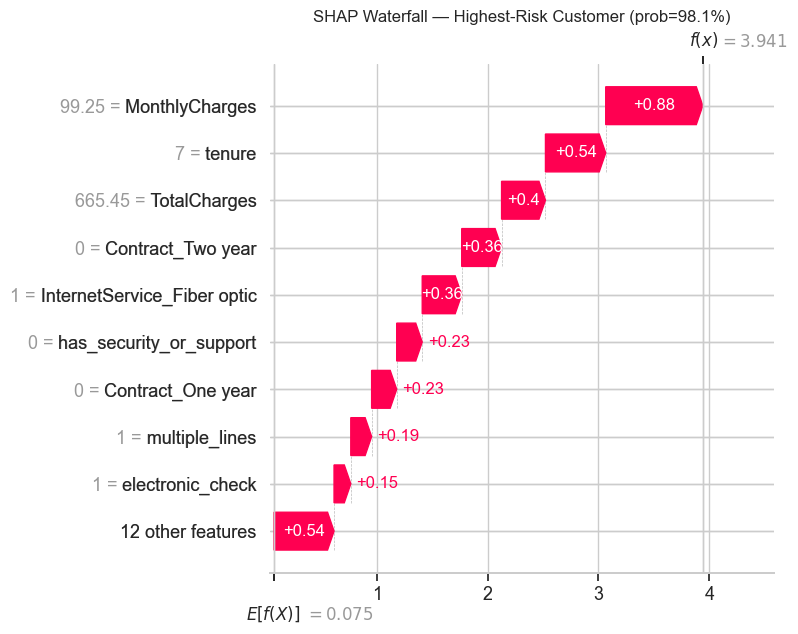

In [89]:
high_risk_idx = np.argmax(chosen_proba)

print(f"Customer index: {high_risk_idx}")
print(f"Predicted churn probability: {chosen_proba[high_risk_idx]:.1%}")
print(f"Actual churn: {'Yes' if y_test.iloc[high_risk_idx] == 1 else 'No'}")

shap.waterfall_plot(shap_values[high_risk_idx], show=False)
plt.title(f"SHAP Waterfall — Highest-Risk Customer (prob={chosen_proba[high_risk_idx]:.1%})")
plt.tight_layout()
plt.savefig('../data/plots/shap_waterfall_high_risk.png', dpi=150, bbox_inches='tight')
plt.show()


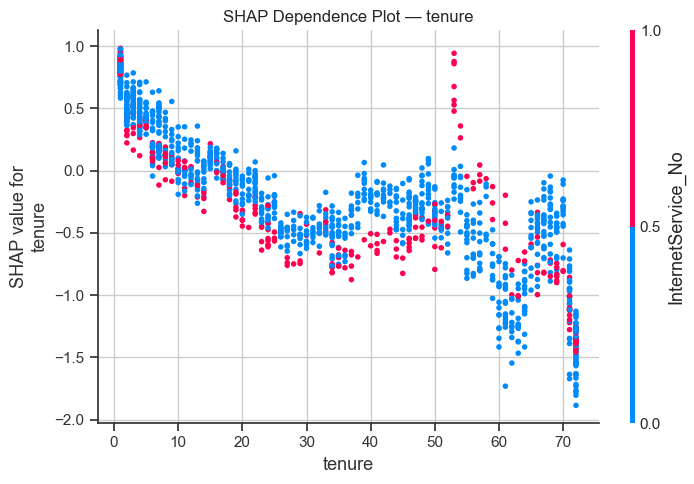

In [90]:
shap.dependence_plot('tenure', shap_values.values, X_test, show=False)
plt.title("SHAP Dependence Plot — tenure")
plt.tight_layout()
plt.savefig('../data/plots/shap_dependence_tenure.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Error and subgroup analysis

Where does the model get it wrong? Breaking false positives/negatives down
by segment shows whether errors are spread evenly or concentrated somewhere
specific — and ties this back to the original EDA.

**Note on `PaymentMethod`:** notebook 02 dropped the raw multi-category
`PaymentMethod` column in favor of a single `electronic_check` flag (the
segment the EDA showed mattered most). That's a deliberate, documented
choice from feature engineering — it means this subgroup breakdown can
distinguish "electronic check vs. other," but not the full four-way payment
method split. Worth stating plainly rather than silently, since it's a real
limitation of what this analysis can show.


In [91]:
error_df = X_test.copy()
error_df['actual'] = y_test.values
error_df['predicted'] = final_preds
error_df['predicted_proba'] = chosen_proba
error_df['outcome'] = np.select(
    [
        (error_df['actual'] == 1) & (error_df['predicted'] == 1),
        (error_df['actual'] == 1) & (error_df['predicted'] == 0),
        (error_df['actual'] == 0) & (error_df['predicted'] == 1),
        (error_df['actual'] == 0) & (error_df['predicted'] == 0),
    ],
    ['true_positive', 'false_negative', 'false_positive', 'true_negative'],
    default='unknown',
)

contract_cols = [c for c in X_test.columns if c.startswith('Contract_')]
tenure_cols = [c for c in X_test.columns if c.startswith('tenure_bucket_')]
internet_cols = [c for c in X_test.columns if c.startswith('InternetService_')]

def dummy_segment(df, cols, prefix, baseline_label):
    """Collapses a set of drop_first one-hot columns back into a single
    readable segment label, including the implied baseline category.
    Strips the exact known prefix (not just the first underscore) since
    some prefixes -- like 'tenure_bucket_' -- contain underscores
    themselves, which a naive split('_', 1) would mangle."""
    seg = pd.Series(baseline_label, index=df.index)
    for c in cols:
        label = c[len(prefix):]
        seg = seg.where(df[c] != 1, label)
    return seg

error_df['contract_segment'] = dummy_segment(error_df, contract_cols, 'Contract_', 'Month-to-month')
error_df['tenure_segment'] = dummy_segment(error_df, tenure_cols, 'tenure_bucket_', '0-6mo')
error_df['internet_segment'] = dummy_segment(error_df, internet_cols, 'InternetService_', 'DSL')
error_df['payment_segment'] = np.where(error_df['electronic_check'] == 1, 'Electronic check', 'Other')

for seg_col, seg_name in [
    ('contract_segment', 'Contract type'),
    ('tenure_segment', 'Tenure bucket'),
    ('internet_segment', 'Internet service'),
    ('payment_segment', 'Payment method (electronic check vs. other)'),
]:
    print(f"=== {seg_name} ===")
    summary = (error_df.groupby(seg_col)
               .agg(n=('actual', 'size'),
                    actual_churn_rate=('actual', 'mean'),
                    false_negative_rate=('outcome', lambda s: (s == 'false_negative').sum() / max((error_df.loc[s.index, 'actual'] == 1).sum(), 1)),
                    false_positive_rate=('outcome', lambda s: (s == 'false_positive').sum() / max((error_df.loc[s.index, 'actual'] == 0).sum(), 1)))
               .round(3))
    print(summary)
    print()


=== Contract type ===
                    n  actual_churn_rate  false_negative_rate  \
contract_segment                                                
Month-to-month    790              0.413                0.153   
One year          290              0.138                0.850   
Two year          327              0.024                1.000   

                  false_positive_rate  
contract_segment                       
Month-to-month                  0.526  
One year                        0.068  
Two year                        0.006  

=== Tenure bucket ===
                  n  actual_churn_rate  false_negative_rate  \
tenure_segment                                                
0-6mo           322              0.525                0.107   
1-2yr           206              0.296                0.213   
2-4yr           315              0.216                0.456   
4+yr            435              0.083                0.583   
6-12mo          129              0.310             

## 11b. Export customer-level data for Power BI

`error_df` already has everything the Overview and Model Performance
dashboard pages need — actual outcomes, predictions, and readable segment
labels — so it's exported as-is rather than rebuilt from scratch.


In [92]:
powerbi_export = error_df[[
    'MonthlyCharges', 'tenure', 'num_services',
    'contract_segment', 'tenure_segment', 'internet_segment', 'payment_segment',
    'actual', 'predicted', 'predicted_proba', 'outcome',
]].copy()

powerbi_export['actual_label'] = powerbi_export['actual'].map({1: 'Churned', 0: 'Stayed'})
powerbi_export['predicted_label'] = powerbi_export['predicted'].map({1: 'Predicted Churn', 0: 'Predicted Stay'})

powerbi_export.to_csv('../data/customer_level_export.csv', index=False)
print(f"Saved customer_level_export.csv  ({powerbi_export.shape[0]:,} rows x {powerbi_export.shape[1]} columns)")
print("Columns:", list(powerbi_export.columns))


Saved customer_level_export.csv  (1,407 rows x 13 columns)
Columns: ['MonthlyCharges', 'tenure', 'num_services', 'contract_segment', 'tenure_segment', 'internet_segment', 'payment_segment', 'actual', 'predicted', 'predicted_proba', 'outcome', 'actual_label', 'predicted_label']


✍️ **YOUR INTERPRETATION HERE**

- Is the false-negative rate (missed churners) noticeably worse in any one
  segment? That's the group a retention team's targeting would systematically
  under-serve.
- Does this connect back to anything from the original EDA (`01_eda.ipynb`)?


## 12. Save outputs for notebook 04

Notebook 04 (retention strategy) consumes this notebook's locked threshold
and test-set predictions directly, rather than re-deriving them — keeping
the threshold decision made exactly once, in exactly one place.


In [93]:
test_predictions = pd.DataFrame({
    'actual': y_test.values,
    'predicted_proba': chosen_proba,
})
test_predictions.to_csv('../data/test_predictions.csv', index=False)

with open('../data/locked_threshold.json', 'w') as f:
    jsonlib.dump({'model': chosen_name, 'locked_threshold': locked_threshold, 'brier_score': float(brier)}, f, indent=2)

joblib.dump(chosen_model, '../data/chosen_model.joblib')

print("Saved test_predictions.csv, locked_threshold.json, chosen_model.joblib")
print("Ready for 04_retention_strategy.ipynb")


Saved test_predictions.csv, locked_threshold.json, chosen_model.joblib
Ready for 04_retention_strategy.ipynb


## 13. Summary

| | Logistic Regression | Random Forest | XGBoost |
|---|---|---|---|
| AUC-ROC | — | — | — |
| PR-AUC | — | — | — |
| F1 (churn) | — | — | — |
| Interpretable? | ✅ Yes (coefficients) | ⚠️ Partial (importances) | ⚠️ Partial (importances) |

*(Fill in from Section 5's results table)*

**Key findings:** *(fill in once you've run this end to end)*

**What this notebook deliberately does NOT do:**
- No business/retention-value calculation — that's notebook 04, using the
  `test_predictions.csv` and locked threshold saved above
- No hyperparameter tuning — the priority was fixing methodology
  (leakage, threshold locking, calibration), not squeezing out marginal
  performance gains
